- Filename: GHSOM_Times.ipynb
- Author: Tomas Hanzlik <hanzlto3@fit.cvut.cz>
- Created: 2026-04-22
- Description: Training and visualizations of the GHSOM model on the TIME Magazine dataset

# GHSOM training on TIME Magazine dataset

In [14]:
import numpy as np
import pandas as pd
from GHSOM import GHSOM
from help_functions import *
from nltk.stem import PorterStemmer, LancasterStemmer
from nltk.stem.snowball import SnowballStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
import nltk

Load data

In [15]:
df = pd.read_csv('../data/Time_magazine.csv')
y = df['file'].to_numpy()
X = df.drop(['file'], axis=1).to_numpy()

Create tokenizer and initialize tfidf vectorizer

In [16]:
stemmer = SnowballStemmer('english')

def english_tokenizer(text):  
    tokens = nltk.word_tokenize(text)
    stems = [stemmer.stem(t) for t in tokens if t.isalpha()]
    return stems

# TF-IDF transformation on the text with filtering on high and low frequency terms
tfidf_vectorizer = TfidfVectorizer(
    tokenizer = english_tokenizer,
    token_pattern = None,
    max_df=0.9,  
    min_df=0.01, 
)

Transform the text data into numerical matrix

In [17]:
X_sparse = tfidf_vectorizer.fit_transform(X.ravel())
X_tfidf = X_sparse.toarray()

Dimension of the embedded feature space

In [18]:
X_tfidf.shape

(420, 3902)

Initialize GHSOM

Details:
- Input dimension of size 3902
- Tau1 parameter of size 0.07
- Tau2 parameter of size 0.0035
- 15 training epoch for each map
- Initial learning rate of 0.5
- Beta of size 0.999
- QE metric used for vertical expansion
- Minimum of 5 samples for vertical expansion
- Maximum map dimension of 30 for individual GSOM
- Euclidean distance used to find neigbors
- Gaussian neigborhood function used
- Exponential decay function used

In [19]:
ghsom_deep = GHSOM(
    input_dim=X_tfidf.shape[1],
    t1=0.07,
    t2=0.0035,
    training_epoch_num=15)

In [20]:
ghsom_deep.train(X_tfidf, y)

Layer 0 Initialized, Global stopping criterion (tau2 * (qe0 or mqe0)): 1.3971
   -> Spawning child 1_0-0 Num of samples: 9, Error: 8.62 > 1.40)
   -> Spawning child 1_0-1 Num of samples: 64, Error: 63.86 > 1.40)
   -> Spawning child 1_1-0 Num of samples: 87, Error: 89.49 > 1.40)
   -> Spawning child 1_2-0 Num of samples: 7, Error: 6.41 > 1.40)
   -> Spawning child 1_2-1 Num of samples: 51, Error: 51.58 > 1.40)
   -> Spawning child 1_3-0 Num of samples: 39, Error: 40.29 > 1.40)
   -> Spawning child 1_3-1 Num of samples: 6, Error: 4.90 > 1.40)
   -> Spawning child 1_4-0 Num of samples: 18, Error: 17.56 > 1.40)
   -> Spawning child 1_4-1 Num of samples: 73, Error: 74.17 > 1.40)
   -> Spawning child 1_5-0 Num of samples: 8, Error: 6.50 > 1.40)
   -> Spawning child 1_5-1 Num of samples: 18, Error: 18.18 > 1.40)
   -> Spawning child 1_6-0 Num of samples: 7, Error: 6.99 > 1.40)
   -> Spawning child 1_6-1 Num of samples: 6, Error: 4.62 > 1.40)
   -> Spawning child 1_7-0 Num of samples: 19, Err

Plot the hierarchical structure

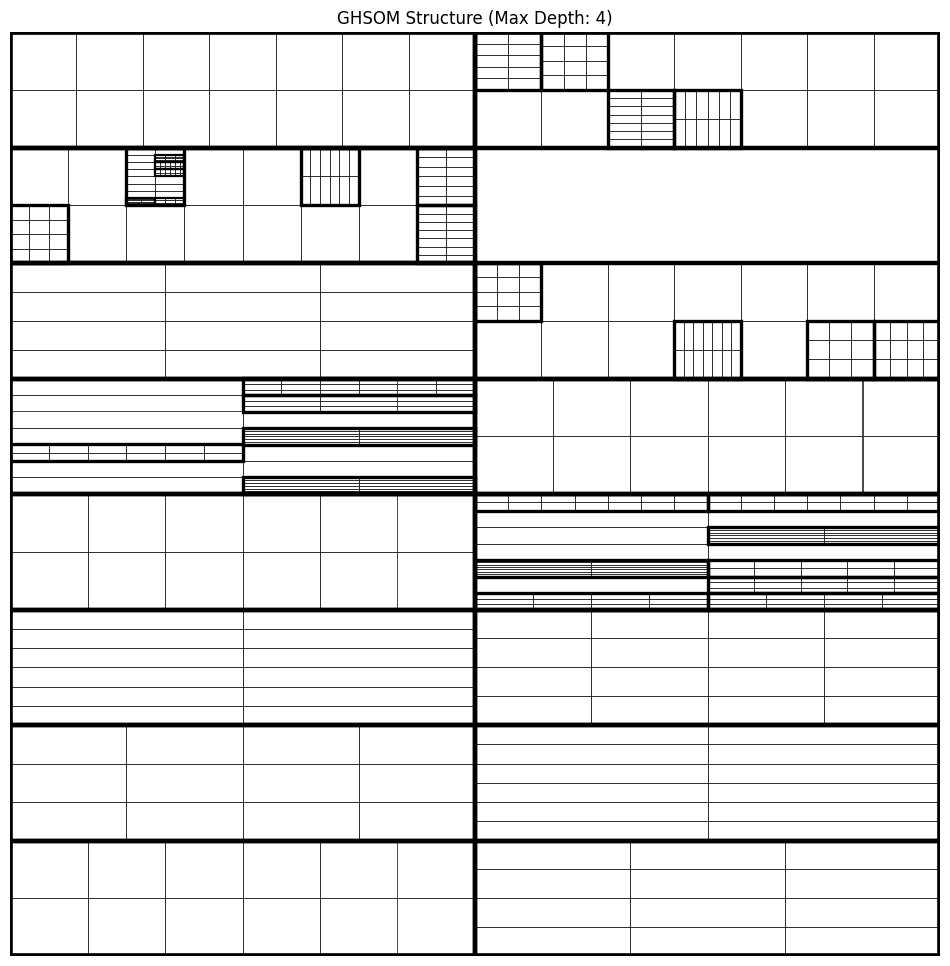

In [21]:
plot_ghsom(ghsom_deep, X_tfidf, y, False)

Describe each cell in the first layer by its top 10 stems

In [22]:
terms = tfidf_vectorizer.get_feature_names_out()

In [23]:
for i in range(ghsom_deep.gsom_db["1"].current_row_num):
    for j in range(ghsom_deep.gsom_db["1"].current_col_num):
        print()
        print("------------------------")
        ghsom_deep.describe_node(X_tfidf, y, terms, "1", (i,j), 10, True)

        if f"1_{i}-{j}" in ghsom_deep.gsom_db.keys():
            sub_rows, sub_cols = ghsom_deep.gsom_db[f"1_{i}-{j}"].current_row_num, ghsom_deep.gsom_db[f"1_{i}-{j}"].current_col_num
            for k in range(sub_rows):
                for l in range(sub_cols):
                    ghsom_deep.describe_node(X_tfidf, y, terms, f"1_{i}-{j}", (k,l), 10, True)


------------------------

Map: 1 | Node: (0, 0)
Top 10 words: marriag, sex, are, agenc, is, fee, love, german, bonn, as, 
Samples: T117.html, T137.html, T144.html, T170.html, T233.html, T342.html, T385.html, T405.html, T471.html, 
Map: 1_0-0 | Node: (0, 0)
Top 10 words: christin, ward, keeler, her, profumo, girl, i, cliveden, miss, she, 
Samples: T170.html, 
Map: 1_0-0 | Node: (0, 1)
Top 10 words: christin, ward, keeler, her, gaull, french, de, profumo, girl, i, 
Samples mapped to this node: 0

Map: 1_0-0 | Node: (0, 2)
Top 10 words: bonn, french, gaull, de, tank, west, germani, german, inflat, increas, 
Samples: T471.html, 
Map: 1_0-0 | Node: (0, 3)
Top 10 words: bonn, west, germani, german, poland, warsaw, polish, marriag, french, perman, 
Samples mapped to this node: 0

Map: 1_0-0 | Node: (0, 4)
Top 10 words: german, germani, bonn, west, marriag, agenc, are, mani, fee, love, 
Samples: T137.html, 
Map: 1_0-0 | Node: (0, 5)
Top 10 words: germani, german, west, is, are, as, bonn, toda